# Đọc dữ liệu

In [1]:
import pandas as pd

# Đường dẫn file CSV
file_path = r'../dataset/vsa_food_review/vsa_food_rv_test.csv'

# Đọc file CSV
df_reviews = pd.read_csv(file_path, encoding='utf-8')

# Kiểm tra dữ liệu
print("Kích thước dữ liệu:", df_reviews.shape)
print("\nCấu trúc DataFrame:")
print(df_reviews.info())
print("\nTop 5 dòng đầu:")
display(df_reviews.head())

print("\nSố lượng review:", len(df_reviews))

Kích thước dữ liệu: (10206, 1)

Cấu trúc DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10206 entries, 0 to 10205
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Comment  10200 non-null  object
dtypes: object(1)
memory usage: 79.9+ KB
None

Top 5 dòng đầu:


,Comment
0,Trà táo 35k\nCookie socola 38k \nNước ở đây bì...
1,Hôm rồi trung tâm mình tổ chức noel party ở đâ...
2,Thịt gà của quán là nhất đấy. Đi ăn gọi liền 4...
3,Hai đứa ăn xong đau bụng cả ngày\nChân gà ok n...
4,Mình vừa thử trưa nay. Điểm cộng đầu tiên là b...



Số lượng review: 10206


## Kiểm tra review trùng lặp

In [2]:
# --- KIỂM TRA VÀ XÓA TRÙNG LẶP ---
# Rename cột về chữ thường
df_reviews.rename(columns={'Comment': 'comment'}, inplace=True)

print(f"Kích thước dữ liệu ban đầu: {df_reviews.shape[0]} dòng")

# Tìm các dòng trùng lặp dựa trên nội dung comment
is_duplicated_rev = df_reviews.duplicated(subset=['comment'], keep='first')
num_duplicates_rev = is_duplicated_rev.sum()

if num_duplicates_rev > 0:
    print(f"Phát hiện {num_duplicates_rev} comment trùng lặp. Đang tiến hành xóa...")
    df_reviews = df_reviews.drop_duplicates(subset=['comment'], keep='first')
    df_reviews = df_reviews.reset_index(drop=True)
    print(f"Đã dọn dẹp xong. Kích thước mới: {df_reviews.shape[0]} dòng")
else:
    print("Không có dữ liệu trùng lặp.")

# Xem thử 5 dòng đầu sau khi kiểm tra trùng lặp
print("\n--- Dữ liệu sau kiểm tra trùng lặp ---")
print(f"Kích thước: {df_reviews.shape}")
display(df_reviews.head())

Kích thước dữ liệu ban đầu: 10206 dòng
Phát hiện 5074 comment trùng lặp. Đang tiến hành xóa...
Đã dọn dẹp xong. Kích thước mới: 5132 dòng

--- Dữ liệu sau kiểm tra trùng lặp ---
Kích thước: (5132, 1)


,comment
0,Trà táo 35k\nCookie socola 38k \nNước ở đây bì...
1,Hôm rồi trung tâm mình tổ chức noel party ở đâ...
2,Thịt gà của quán là nhất đấy. Đi ăn gọi liền 4...
3,Hai đứa ăn xong đau bụng cả ngày\nChân gà ok n...
4,Mình vừa thử trưa nay. Điểm cộng đầu tiên là b...


--- THÔNG KÊ SAU KHI LỌC ---
- Đã xóa: 196 review quá dài.
- Còn lại: 4936 review.
- Review dài nhất hiện tại: 256 từ.


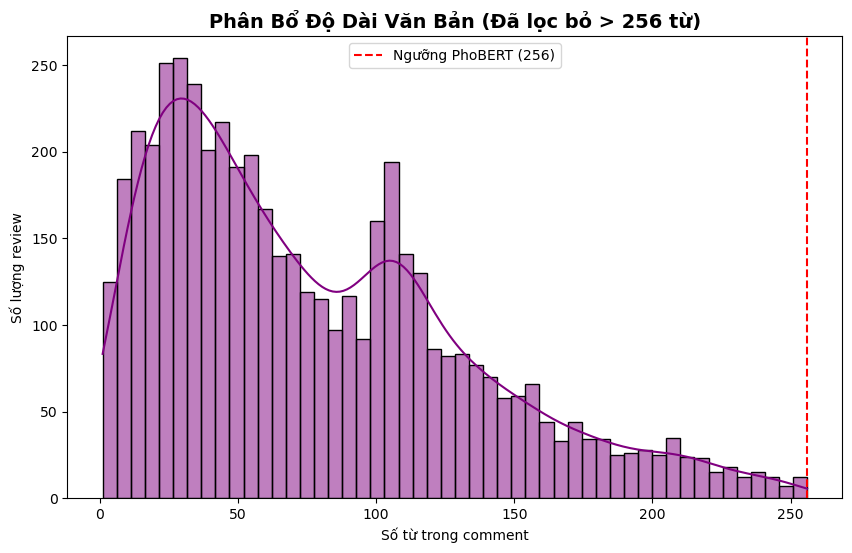

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán cột word_count để lọc
df_reviews['word_count'] = df_reviews['comment'].apply(lambda x: len(str(x).split()))

# 2. Thực hiện lọc bỏ những dòng > 256 từ
initial_count = len(df_reviews)
df_reviews = df_reviews[df_reviews['word_count'] <= 256].reset_index(drop=True)

# 3. Tính toán lại báo cáo sau khi lọc
final_count = len(df_reviews)
removed_count = initial_count - final_count
max_len_after = df_reviews['word_count'].max()

# 4. Trực quan hóa kết quả sau lọc
plt.figure(figsize=(10, 6))
sns.histplot(df_reviews['word_count'], bins=50, kde=True, color='purple')
plt.axvline(x=256, color='red', linestyle='--', label='Ngưỡng PhoBERT (256)')
plt.title('Phân Bổ Độ Dài Văn Bản (Đã lọc bỏ > 256 từ)', fontsize=14, fontweight='bold')
plt.xlabel('Số từ trong comment')
plt.ylabel('Số lượng review')
plt.legend()

print(f"--- THÔNG KÊ SAU KHI LỌC ---")
print(f"- Đã xóa: {removed_count} review quá dài.")
print(f"- Còn lại: {final_count} review.")
print(f"- Review dài nhất hiện tại: {max_len_after} từ.")
plt.show()


In [4]:
import re
import pandas as pd
import unicodedata

# Tạo các thùng chứa (Log) để lưu kết quả truy vết cho từng lỗi
fixed_encoding = []
fixed_invisible = []
fixed_whitespace = []
fixed_non_alpha = []

def process_token(token):
    """
    Xử lý từng token (từ được phân tách bởi khoảng trắng).
    Quyết định giữ nguyên, làm sạch, hoặc xóa hoàn toàn.
    """
    # Giữ nguyên nếu token chỉ toàn chữ cái (không số, không ký tự đặc biệt)
    if not re.search(r'[\d\W]', token) or token == ',':
        return token

    # Tách dấu phẩy cuối token ra để xử lý riêng (VD: "50k," → core="50k", suffix=",")
    suffix = ''
    core = token
    if token.endswith(','):
        suffix = ','
        core = token[:-1]

    # Các pattern số hợp lệ → GIỮ LẠI
    if re.fullmatch(r'\d+[khp]', core):    # số+k / số+h / số+p : 50k, 22h, 30p
        return core + suffix
    if re.fullmatch(r'\d+/\d+', core):     # số/số                : 5/5, 1/2
        return core + suffix
    if re.fullmatch(r'\d+', core):         # số đứng độc lập      : 3 người, order 2 món
        return core + suffix

    # Còn lại: xóa ký tự đặc biệt + số, chỉ giữ chữ cái và dấu phẩy
    # VD: "3ng"→"ng", "<3"→"", "=))"→"", "covid19"→"covid", "24km"→"km"
    cleaned = re.sub(r'[^\w,]|_|\d', '', token)
    return cleaned if cleaned else ''

def track_and_clean(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""

    step_0 = text

    # --- BƯỚC 0.5: Chuẩn hóa Unicode ---
    step_0 = unicodedata.normalize('NFC', step_0)

    # --- BƯỚC 1: Sửa lỗi mã hóa (Mojibake) ---
    step_1 = step_0
    try:
        decoded = step_0.encode('latin1').decode('utf-8')
        if decoded != step_0:
            step_1 = decoded
            fixed_encoding.append({"old": step_0, "new": step_1})
    except:
        pass

    # --- BƯỚC 2: Loại bỏ ký tự ẩn ---
    step_2 = re.sub(r'[\u200b\u200c\u200d\u200e\u200f\ufeff]+', '', step_1)
    step_2 = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', step_2)
    if step_2 != step_1:
        fixed_invisible.append({"old": repr(step_1), "new": repr(step_2)})

    # --- BƯỚC 3: Xử lý khoảng trắng lộn xộn & Xuống dòng ---
    step_3 = re.sub(r'[\r\n\t]+', ' ', step_2)
    step_3 = re.sub(r'\s+', ' ', step_3).strip()
    if step_3 != step_2:
        fixed_whitespace.append({"old": repr(step_2), "new": repr(step_3)})

    # --- BƯỚC 4: Chuyển toàn bộ về chữ thường ---
    step_4 = step_3.lower()

    # --- BƯỚC 5: XỬ LÝ DẤU CÂU & SỐ ---
    # Bước 5a: Thay dấu chấm → dấu phẩy (giữ lại điểm ngắt câu)
    step_5 = step_4.replace('.', ',')

    # Bước 5b: Xử lý từng token theo rule
    # Tách theo space → xử lý → ghép lại
    tokens = step_5.split(' ')
    processed = [process_token(t) for t in tokens]
    step_5 = ' '.join(t for t in processed if t)

    # Bước 5c: Dọn khoảng trắng lần cuối
    step_5 = re.sub(r'\s+', ' ', step_5).strip()

    if step_5 != step_4:
        fixed_non_alpha.append({"old": step_4, "new": step_5})

    return step_5

# ==========================================
# KHỞI CHẠY
# ==========================================
print(f"Đang quét dọn {len(df_reviews)} bình luận. Vui lòng chờ...")
initial_count = len(df_reviews)

df_reviews['comment'] = df_reviews['comment'].apply(track_and_clean)

# Xóa review rỗng sau khi làm sạch
df_reviews = df_reviews[df_reviews['comment'] != ''].reset_index(drop=True)
empty_removed_count = initial_count - len(df_reviews)

# ==========================================
# IN RA MINH CHỨNG (SHOW LOG)
# ==========================================
print("\n" + "="*80)
print(f"[BƯỚC 1] LUẬT ENCODING: Lôi ra ánh sáng {len(fixed_encoding)} review lỗi Font chữ")

print("\n" + "="*80)
print(f"[BƯỚC 2] KÝ TỰ TÀNG HÌNH: Đã bóc mẽ {len(fixed_invisible)} review")

print("\n" + "="*80)
print(f"[BƯỚC 3] KHOẢNG TRẮNG / XUỐNG DÒNG: Đã là phẳng {len(fixed_whitespace)} review bị ngắt dòng")

print("\n" + "="*80)
print(f"[BƯỚC 4 & 5] DỌN SẠCH DẤU CÂU & CHỮ SỐ: Đã chuẩn hóa {len(fixed_non_alpha)} review")
print(f"             GIỮ LẠI : số+k (50k) | số+h (22h) | số+p (30p) | số/số (5/5) | số đứng độc lập (3 người)")
print(f"             XÓA     : ký tự đặc biệt (<3 =)> ...) | số dính chữ (covid19, 3ng, 24km)")
print(f"             THAY    : dấu chấm '.' → dấu phẩy ','")
for i, item in enumerate(fixed_non_alpha[:5]):
    print(f"  ❌ [Gốc]: {item['old']}")
    print(f"  ✅ [Mới]: {item['new']}\n")

print("\n" + "="*80)
print(f"[BƯỚC CHUNG] DỮ LIỆU RỖNG: Đã phát hiện và xóa {empty_removed_count} review trống")
print(f"-> Tổng số review còn lại sau khi dọn dẹp: {len(df_reviews)}\n")

print("--- VÍ DỤ SAU TIỀN XỬ LÝ (5 REVIEW ĐẦU) ---")
display(df_reviews[['comment']].head(5))

Đang quét dọn 4936 bình luận. Vui lòng chờ...

[BƯỚC 1] LUẬT ENCODING: Lôi ra ánh sáng 0 review lỗi Font chữ

[BƯỚC 2] KÝ TỰ TÀNG HÌNH: Đã bóc mẽ 15 review

[BƯỚC 3] KHOẢNG TRẮNG / XUỐNG DÒNG: Đã là phẳng 2417 review bị ngắt dòng

[BƯỚC 4 & 5] DỌN SẠCH DẤU CÂU & CHỮ SỐ: Đã chuẩn hóa 4479 review
             GIỮ LẠI : số+k (50k) | số+h (22h) | số+p (30p) | số/số (5/5) | số đứng độc lập (3 người)
             XÓA     : ký tự đặc biệt (<3 =)> ...) | số dính chữ (covid19, 3ng, 24km)
             THAY    : dấu chấm '.' → dấu phẩy ','
  ❌ [Gốc]: trà táo 35k cookie socola 38k nước ở đây bình thường, nhưng giá hơi chát ạ không gian quán giống với nhiều quán khác phục bình thường, chỉ có 2 người phục vụ. đợi nước hơi bị lâu í nói chung là delio ở nơi khác thì mình không biết thế nào nhưng ở hồ đắc di thì nhạt quá ạ 😭😭
  ✅ [Mới]: trà táo 35k cookie socola 38k nước ở đây bình thường, nhưng giá hơi chát ạ không gian quán giống với nhiều quán khác phục bình thường, chỉ có 2 người phục vụ, đợi nước 

,comment
0,trà táo 35k cookie socola 38k nước ở đây bình ...
1,hôm rồi trung tâm mình tổ chức noel party ở đâ...
2,"thịt gà của quán là nhất đấy, đi ăn gọi liền 4..."
3,hai đứa ăn xong đau bụng cả ngày chân gà ok nh...
4,"mình vừa thử trưa nay, điểm cộng đầu tiên là b..."


## Xử lý teencode (Kéo dài từ)

In [5]:
import re
import pandas as pd

def remove_elongation(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Regex để tìm ký tự lặp lại 3 lần trở lên
    pattern = r'([a-zđáàãảạâấầẫẩậăắằẵẳặéèẽẻẹêếềễểệíìĩỉịóòõỏọôốồỗổộơớờỡởợúùũủụưứừữửựýỳỹỷỵ])\1{2,}'
    
    # Thay thế về 1 ký tự duy nhất
    text = re.sub(pattern, r'\1', text, flags=re.IGNORECASE)
    
    # === BƯỚC MỚI: XÓA DẤU PHẨY LIÊN TIẾP ===
    # Thay thế nhiều dấu phẩy liên tiếp (,,,) thành 1 dấu phẩy
    text = re.sub(r',+', ',', text)
    
    # Chuẩn hóa khoảng trắng xung quanh dấu phẩy (tránh " , , ," → " , ")
    text = re.sub(r'\s*,\s*', ', ', text)
    
    # Dọn dẹp khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Lưu cột gốc để so sánh
df_reviews['comment_old'] = df_reviews['comment']

print("Đang dọn dẹp các ký tự bị kéo dài (VD: ngonnnn -> ngon)...\n")
print("Đang xóa dấu phẩy liên tiếp (VD: tầm trung , , , mới → tầm trung , mới)...\n")
df_reviews['comment'] = df_reviews['comment'].apply(remove_elongation)

# Thống kê kết quả
changed_rows = (df_reviews['comment'] != df_reviews['comment_old']).sum()
print(f"--- THỰC HIỆN XONG ---")
print(f"Tổng số bình luận bị thay đổi: {changed_rows} dòng")

if changed_rows > 0:
    # Hiển thị ví dụ trước/sau
    changed_df = df_reviews[df_reviews['comment'] != df_reviews['comment_old']]
    print(f"\n--- {min(3, len(changed_df))} VÍ DỤ TRƯỚC/SAU ---")
    for idx, (before, after) in enumerate(zip(changed_df['comment_old'].head(3), changed_df['comment'].head(3))):
        print(f"\n{idx+1}. Trước: {before[:200]}...")
        print(f"   Sau:   {after[:200]}...")
else:
    print("✅ Dữ liệu đã sạch!")

# Xóa cột tạm
df_reviews = df_reviews.drop(columns=['comment_old'])

# Hiển thị sample
print(f"\n--- 5 DÒNG ĐẦU SAU XỬ LÝ ---")
display(df_reviews.head())

Đang dọn dẹp các ký tự bị kéo dài (VD: ngonnnn -> ngon)...

Đang xóa dấu phẩy liên tiếp (VD: tầm trung , , , mới → tầm trung , mới)...

--- THỰC HIỆN XONG ---
Tổng số bình luận bị thay đổi: 1544 dòng

--- 3 VÍ DỤ TRƯỚC/SAU ---

1. Trước: hôm rồi trung tâm mình tổ chức noel party ở đây vì mua được voucher kngười suất buffet lẩu ạ, nhà hàng nằm trên đầu đường thái thịnh rất to, nhìn có vẻ chuyên về hội nghị tiệc cưới hơn, bởi vậy nên bu...
   Sau:   hôm rồi trung tâm mình tổ chức noel party ở đây vì mua được voucher kngười suất buffet lẩu ạ, nhà hàng nằm trên đầu đường thái thịnh rất to, nhìn có vẻ chuyên về hội nghị tiệc cưới hơn, bởi vậy nên bu...

2. Trước: ngon bổ rẻ , ấn tượng tương ớt chấm rất ngon, mỗi tội hơi ít món, cần nâng thêm vài món nhậu nữa...
   Sau:   ngon bổ rẻ, ấn tượng tương ớt chấm rất ngon, mỗi tội hơi ít món, cần nâng thêm vài món nhậu nữa...

3. Trước: không gian thoáng đãng, ngồi trên tầng 2 nhìn được cảnh đẹp, không quá ồn , cách bài trí ấm áo do có các lồng đèn

,comment,word_count
0,trà táo 35k cookie socola 38k nước ở đây bình ...,62
1,hôm rồi trung tâm mình tổ chức noel party ở đâ...,184
2,"thịt gà của quán là nhất đấy, đi ăn gọi liền 4...",154
3,hai đứa ăn xong đau bụng cả ngày chân gà ok nh...,15
4,"mình vừa thử trưa nay, điểm cộng đầu tiên là b...",65


## Chuẩn hóa Teencode, Viết tắt

In [6]:
import pandas as pd
import re
import os

# ============================================================
# BƯỚC 1: TỪ ĐIỂN VIẾT TẮT / TEENCODE THỦ CÔNG
# ============================================================
# ============================================================
# BƯỚC 1: TỪ ĐIỂN VIẾT TẮT / TEENCODE / TIẾNG ANH (CẬP NHẬT)
# ============================================================
ABBREV_DICT = {
    # 1. TỪ PHỦ ĐỊNH / TỪ NỐI / TRẠNG TỪ
    "ko": "không", "k": "không", "kh": "không", "kg": "không", "kog": "không", 
    "khg": "không", "hong": "không", "hok": "không", "khom": "không", "khong": "không",
    "vs": "với", "cx": "cũng", "cg": "cũng", "cũg": "cũng", "cux": "cũng", 
    "trc": "trước", "truoc": "trước", "th": "thì",
    "lun": "luôn", "luon": "luôn", "luonn": "luôn", "luônn": "luôn",
    "r": "rồi", "rùi": "rồi", "rui": "rồi", "ròi": "rồi", "xog": "xong",
    "z": "vậy", "vz": "vậy", "zậy": "vậy", "zui": "vui", "dzui": "vui",
    "j": "gì", "qá": "quá", "qa": "quá", "quáa": "quá", "rât": "rất",
    "nhma": "nhưng mà", "nma": "nhưng mà", "nhg": "nhưng",
    "nchung": "nói chung", "nc": "nói chung", "nch": "nói chung",
    "bt": "bình thường", "bth": "bình thường", "bthg": "bình thường", "bthuong": "bình thường",
    "vc": "vô cùng", "vcl": "vô cùng", "vl": "vô cùng", "vch": "vô cùng",
    "ntn": "như thế nào", "ms": "mới",

    # 2. NGƯỜI / ĐẠI TỪ
    "nv": "nhân viên", "nvien": "nhân viên", "nvpv": "nhân viên phục vụ",
    "ng": "người", "ngta": "người ta", "ngừoi": "người", "nguoi": "người", "ngươ": "người",
    "mk": "mình", "mik": "mình", "tui": "tôi", "t": "tôi",
    "mn": "mọi người", "mng": "mọi người", "mnguoi": "mọi người",
    "bn": "bạn", "b": "bạn", "ae": "anh em", "ce": "chị em",
    "gd": "gia đình", "gđ": "gia đình", "gdinh": "gia đình",

    # 3. THUẬT NGỮ NHÀ HÀNG / DỊCH VỤ / TRẢI NGHIỆM
    "đc": "được", "dc": "được", "dk": "được", "đk": "được", "đươc": "được",
    "ql": "quản lý", "qly": "quản lý", "cskh": "chăm sóc khách hàng",
    "pv": "phục vụ", "pvu": "phục vụ", "phuc": "phục vụ",
    "kh": "khách hàng", # (tùy ngữ cảnh, có thể là 'không')
    "ch": "cửa hàng", "nh": "nhà hàng", "cn": "chi nhánh",
    "đt": "điện thoại", "dt": "điện thoại",
    "ck": "chuyển khoản", "tt": "thanh toán", "vat": "thuế VAT",
    "km": "khuyến mãi", "sp": "sản phẩm", "cty": "công ty",
    "đb": "đặc biệt", "dbiet": "đặc biệt",
    "kgian": "không gian", "csvc": "cơ sở vật chất",
    "dth": "dễ thương", "dthw": "dễ thương", "dthuong": "dễ thương",
    "mlem": "ngon", "thik": "thích", "thix": "thích",
    "hssv": "học sinh sinh viên", "hs": "học sinh", "sv": "sinh viên",
    "sn": "sinh nhật",
    "thit": "thịt", "nuoc": "nước", "nhiet": "nhiệt", "thuong": "thương",

    # 4. THỜI GIAN / ĐỊA DANH
    "hnay": "hôm nay", "hm": "hôm nay",
    "hqua": "hôm qua", "hqa": "hôm qua",
    "tgian": "thời gian", "tg": "thời gian",
    "hcm": "Hồ Chí Minh", "tphcm": "TP. Hồ Chí Minh",
    "hn": "Hà Nội", "sg": "Sài Gòn", "tp": "thành phố",
    "vn": "Việt Nam", "hq": "Hàn Quốc",
    "pmh": "Phú Mỹ Hưng", "svh": "Sư Vạn Hạnh",

    # 5. SỬA LỖI CHÍNH TẢ / CẢM THÁN KÉO DÀI
    "ok": "ok", "oke": "ok", "okela": "ok", "okila": "ok", "okey": "ok", "oki": "ok",
    "ngonn": "ngon", "lắmm": "lắm",
    "nhaa": "nha", "ạa": "ạ", "ạaa": "ạ", "nhee": "nhé",
    "tr": "trời", "chời": "trời",
    "haha": "haha", "hihi": "hihi", "huhu": "huhu",

    # 6. TIẾNG ANH: VIẾT TẮT / SAI CHÍNH TẢ -> TIẾNG ANH CHUẨN
    "rcm": "recommend", "rec": "recommend", "recomend": "recommend", "reccomend": "recommend",
    "ord": "order", "oder": "order",
    "rv": "review",
    "cmt": "comment", "rep": "reply",
    "fb": "facebook", "ig": "instagram", "ib": "inbox",
    "wf": "wifi", "cf": "cafe",
    "stt": "status", "app": "application",
    "toping": "topping", "toppings": "topping",
    "dishes": "dish", "noodles": "noodle", "prices": "price", "services": "service",
    "takecare": "take care", "chilli": "chili",

    # 7. TIẾNG ANH & NGOẠI LAI (CHUẨN HÓA MỘT SỐ TÊN GỌI)
    "panchan": "banchan", "pancha": "banchan",
    "kimbab": "kimbap",
    "tokbokki": "tokbokki", "tok": "tokbokki", "tteokbokki": "tokbokki", "tobokki": "tokbokki",
    "phomai": "phô mai",
    "vnd": "VNĐ", "vnđ": "VNĐ",
    "nvs": "WC", "wc": "WC",
    "qr": "QR",

    
}

# BƯỚC 2: HÀM NORMALIZE VIẾT TẮT

def normalize_text(text: str) -> str:
    """Thay thế từ viết tắt bằng từ đầy đủ dựa theo ABBREV_DICT."""
    if not isinstance(text, str):
        return ""
        
    words = text.split()
    normalized = []
    for w in words:
        w_lower = w.lower()
        if w_lower in ABBREV_DICT:
            normalized.append(ABBREV_DICT[w_lower])
        else:
            normalized.append(w)
    return " ".join(normalized)

# BƯỚC 3: ÁP DỤNG THAY ĐỔI

# Giả sử bạn đang có dataframe `df_reviews`
# Xóa các dòng comment bị rỗng (NaN)
df_reviews = df_reviews.dropna(subset=['comment']).copy()

# (Tuỳ chọn) Nếu bạn muốn ghi đè trực tiếp lên cột comment cũ, sử dụng lệnh dưới đây:
df_reviews['comment'] = df_reviews['comment'].apply(normalize_text)

print("Đã hoàn thành việc quy đổi từ viết tắt!")

Đã hoàn thành việc quy đổi từ viết tắt!


## 2. Tần suất xuất hiện N-grams (Từ vựng)

Tổng số review để phân tích: 4932
Tổng số Unigrams: 7446
Tổng số Bigrams: 119136


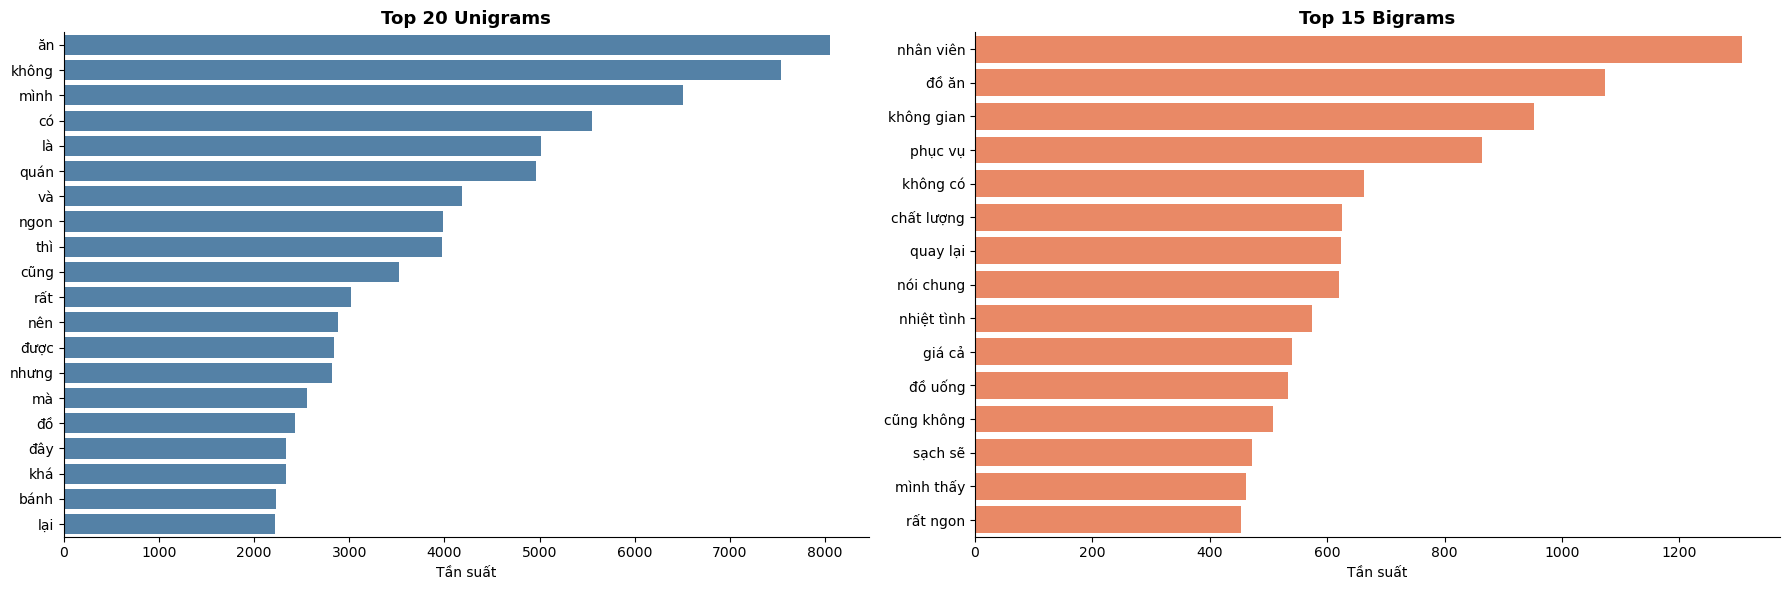


✅ Đã xuất toàn bộ N-grams tại: ../dataset/preprocessed\all_ngrams_vsa_test.csv
   Tổng số dòng: 126,582
✅ Đã xuất riêng 1-grams tại: ../dataset/preprocessed\unigrams_vsa_test.csv
   Tổng số dòng: 7,446

--- TOP 10 UNIGRAMS PHỔ BIẾN NHẤT ---
1. 'ăn': 8,057
2. 'không': 7,537
3. 'mình': 6,508
4. 'có': 5,552
5. 'là': 5,018
6. 'quán': 4,960
7. 'và': 4,187
8. 'ngon': 3,988
9. 'thì': 3,976
10. 'cũng': 3,524

--- TOP 10 BIGRAMS PHỔ BIẾN NHẤT ---
1. 'nhân viên': 1,306
2. 'đồ ăn': 1,074
3. 'không gian': 952
4. 'phục vụ': 864
5. 'không có': 662
6. 'chất lượng': 625
7. 'quay lại': 624
8. 'nói chung': 621
9. 'nhiệt tình': 575
10. 'giá cả': 540


In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Hàm phụ trợ để trích xuất N-gram từ một tập văn bản
def get_top_ngrams(corpus, n=None, ngram_range=(1, 1)):
    if len(corpus) == 0: 
        return []
    
    # Khởi tạo CountVectorizer
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    # Lấy danh sách từ và tần suất
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    # Sắp xếp giảm dần theo tần suất
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    # Nếu n=None, trả về toàn bộ danh sách
    return words_freq if n is None else words_freq[:n]

# Hàm vẽ biểu đồ (Trực quan hóa)
def plot_ngrams(ax, data, title, color):
    if not data: # Bỏ qua nếu không có dữ liệu
        return
    df_ngrams = pd.DataFrame(data, columns=['N-gram', 'Tần suất'])
    sns.barplot(x='Tần suất', y='N-gram', data=df_ngrams, ax=ax, color=color)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Tần suất')
    ax.set_ylabel('')

# Lấy corpus từ tất cả các comment
corpus = df_reviews['comment'].dropna()
print(f"Tổng số review để phân tích: {len(corpus)}")

# RÚT TRÍCH TOÀN BỘ N-GRAMS
all_unigrams = get_top_ngrams(corpus, n=None, ngram_range=(1, 1))
all_bigrams = get_top_ngrams(corpus, n=None, ngram_range=(2, 2))

print(f"Tổng số Unigrams: {len(all_unigrams)}")
print(f"Tổng số Bigrams: {len(all_bigrams)}")

# Tạo không gian vẽ hai biểu đồ (1 hàng x 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Vẽ biểu đồ
plot_ngrams(axes[0], all_unigrams[:20], 'Top 20 Unigrams', 'steelblue')
plot_ngrams(axes[1], all_bigrams[:15],  'Top 15 Bigrams', 'coral')

plt.tight_layout()
sns.despine()
plt.show()

# ====================================================
# XUẤT DỮ LIỆU RA FILE DƯỚI DẠNG CSV
# ====================================================

# Đảm bảo thư mục lưu trữ đã tồn tại
save_dir = '../dataset/preprocessed'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 1. XUẤT TOÀN BỘ N-GRAMS (Unigrams + Bigrams)
all_ngrams_data = []
for ngram, freq in all_unigrams:
    all_ngrams_data.append({'Loại': 'Unigram', 'N-gram': ngram, 'Tần suất': freq})
for ngram, freq in all_bigrams:
    all_ngrams_data.append({'Loại': 'Bigram', 'N-gram': ngram, 'Tần suất': freq})

df_all_ngrams = pd.DataFrame(all_ngrams_data)
all_ngrams_path = os.path.join(save_dir, 'all_ngrams_vsa_test.csv')
df_all_ngrams.to_csv(all_ngrams_path, index=False, encoding='utf-8-sig')

print(f"\n✅ Đã xuất toàn bộ N-grams tại: {all_ngrams_path}")
print(f"   Tổng số dòng: {len(df_all_ngrams):,}")

# 2. XUẤT RIÊNG CHỈ 1-GRAMS (Unigrams)
df_unigrams = pd.DataFrame(all_unigrams, columns=['N-gram', 'Tần suất'])
unigrams_path = os.path.join(save_dir, 'unigrams_vsa_test.csv')
df_unigrams.to_csv(unigrams_path, index=False, encoding='utf-8-sig')

print(f"✅ Đã xuất riêng 1-grams tại: {unigrams_path}")
print(f"   Tổng số dòng: {len(df_unigrams):,}")

print(f"\n--- TOP 10 UNIGRAMS PHỔ BIẾN NHẤT ---")
for i, (ngram, freq) in enumerate(all_unigrams[:10], 1):
    print(f"{i}. '{ngram}': {freq:,}")

print(f"\n--- TOP 10 BIGRAMS PHỔ BIẾN NHẤT ---")
for i, (ngram, freq) in enumerate(all_bigrams[:10], 1):
    print(f"{i}. '{ngram}': {freq:,}")

In [8]:
# Cài đặt trước:
# !pip install pyvi -q
# hoặc
# !pip install underthesea -q

import pandas as pd
import os

# ============================================================
# DANH SÁCH TỪ TIẾNG VIỆT CHUẨN
# ============================================================
vietnamese_words = {
    # Từ chức năng
    "là", "và", "có", "mà", "để", "từ", "vì", "sẽ", "đã", "được", "cả", "bị", 
    "không", "ko", "khong", "về", "ra", "đi", "gì", "như",
    
    # Danh từ phổ biến
    "ăn", "đồ", "vị", "gà", "bò", "cơm", "thịt", "cá", "rau", "quán", "nhà",
    "người", "bạn", "thời", "ngày", "tháng", "năm", "tuần", "lúc", "giờ",
    "cửa", "hàng", "tiền", "giá", "món", "chỗ", "nơi", "địa", "điểm",
    
    # Vị từ phổ biến
    "ngon", "ngắn", "dài", "tốt", "xấu", "đẹp", "trẻ", "lớn", "nhỏ", "nóng",
    "lạnh", "tươi", "cũ", "mới", "sạch", "bẩn", "đắt", "rẻ", "nhiều", "ít",
    
    # Trạng từ
    "rất", "quá", "lắm", "hơi", "hết", "luôn", "chỉ", "vừa", "sắp", "đang",
}

# ============================================================
# ĐỌC DỮ LIỆU
# ============================================================
unigrams_path = r'../dataset/preprocessed/unigrams_vsa_test.csv'
df_uni = pd.read_csv(unigrams_path)
print(f"Đã đọc {len(df_uni):,} unigrams từ file.\n")

# ============================================================
# HÀM KIỂM TRA (CẬP NHẬT)
# ============================================================
def needs_processing(word):
    w = str(word).lower().strip()
    
    # 🛡️ CẤP 1: BẢO VỆ TEENCODE 1-2 ký tự
    if len(w) <= 2:
        return True  # CẦN XỬ LÝ (teencode)
    
    # 🛡️ CẤP 2: Kiểm tra danh sách từ tiếng Việt phổ biến
    if w in vietnamese_words:
        return False  # KHÔNG cần xử lý
    
    # CẤP 3: Nếu không phải từ phổ biến → CẦN XỬ LÝ
    return True

# ============================================================
# LỌC VÀ GỘP NHÓM
# ============================================================
print("Đang quét để lọc từ cần xử lý...\n")

df_can_xu_ly = df_uni[df_uni['N-gram'].apply(needs_processing)].copy()
df_can_xu_ly = df_can_xu_ly.groupby('N-gram')['Tần suất'].sum().reset_index()
df_can_xu_ly = df_can_xu_ly.sort_values(by='Tần suất', ascending=False)

# ============================================================
# LƯU KẾT QUẢ
# ============================================================
save_dir = '../dataset/preprocessed'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

output_path = os.path.join(save_dir, 'tu_can_xu_ly_thu_cong_vsa_test.csv')
df_can_xu_ly.to_csv(output_path, index=False, encoding='utf-8-sig')


# ============================================================
# BÁO CÁO
# ============================================================
print(f"✅ Đã hoàn tất lọc dữ liệu!")
print(f"- Tổng từ cần xử lý: {len(df_can_xu_ly):,} từ")
print(f"- Từ bỏ qua: {len(df_uni) - len(df_can_xu_ly):,} từ (tiếng Việt chuẩn)\n")

print(f"💾 File lưu tại:")
print(f"{output_path}")

print("--- TOP 30 TỪ XUẤT HIỆN NHIỀU NHẤT CẦN XỬ LÝ ---")
display(df_can_xu_ly.head(30))

Đã đọc 7,446 unigrams từ file.

Đang quét để lọc từ cần xử lý...

✅ Đã hoàn tất lọc dữ liệu!
- Tổng từ cần xử lý: 7,392 từ
- Từ bỏ qua: 54 từ (tiếng Việt chuẩn)

💾 File lưu tại:
../dataset/preprocessed\tu_can_xu_ly_thu_cong_vsa_test.csv
--- TOP 30 TỪ XUẤT HIỆN NHIỀU NHẤT CẦN XỬ LÝ ---


,N-gram,Tần suất
7002,ăn,8057
3684,mình,6508
1466,có,5552
3227,là,5018
6557,và,4187
5762,thì,3976
1494,cũng,3524
4384,nên,2881
4190,nhưng,2816
3646,mà,2553


In [9]:
import pandas as pd
import re

# ============================================================
# BƯỚC 1: ĐỌC FILE TỪ ĐIỂN
# ============================================================
dict_path = '../dataset/preprocessed/tu_can_xu_ly_thu_cong_vsa_test_dich.csv' 

try:
    df_dict = pd.read_csv(dict_path, encoding='utf-8')
    print(f"✅ Đã đọc thành công file từ điển với {len(df_dict)} từ.\n")
    
    # Kiểm tra cột có tồn tại không (kiểm tra cả 'Dịch' và 'dịch')
    if 'Dịch' not in df_dict.columns and 'dịch' not in df_dict.columns:
        print(f"❌ Lỗi: File không có cột 'Dịch'. Các cột hiện có: {list(df_dict.columns)}")
        abbreviation_mapping = {}
    else:
        # Xác định tên cột (có thể là 'Dịch' hoặc 'dịch')
        col_name = 'Dịch' if 'Dịch' in df_dict.columns else 'dịch'
        
        # Chỉ lấy các từ có tồn tại giá trị ở cột 'Dịch' (loại bỏ hàng trống)
        df_dict_valid = df_dict.dropna(subset=[col_name])
        df_dict_valid = df_dict_valid[df_dict_valid[col_name].astype(str).str.strip() != '']
        
        # CHUYỂN THÀNH DICTIONARY
        abbreviation_mapping = dict(zip(
            df_dict_valid['N-gram'].astype(str).str.lower().str.strip(), 
            df_dict_valid[col_name].astype(str).str.lower().str.strip()
        ))
        
        print(f"📊 Thống kê:")
        print(f"   - Tổng từ trong file: {len(df_dict)}")
        print(f"   - Từ đã điền (có cột {col_name}): {len(df_dict_valid)}")
        print(f"   - Từ trong từ điển hoạt động: {len(abbreviation_mapping)}\n")
    
except FileNotFoundError:
    print(f"❌ Không tìm thấy file: {dict_path}")
    abbreviation_mapping = {}
except Exception as e:
    print(f"❌ Lỗi khi đọc file: {e}")
    abbreviation_mapping = {}

# ============================================================
# BƯỚC 2: HÀM THAY THẾ TỪ (CẬP NHẬT)
# ============================================================
def replace_words_from_dict(text):
    """Thay thế từ viết tắt/slang bằng từ đầy đủ."""
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Tách thành các từ
    words = text.split()
    replaced_words = []
    
    for word in words:
        word_lower = word.lower().strip()
        # Kiểm tra từ này có trong từ điển không
        if word_lower in abbreviation_mapping:
            replaced_words.append(abbreviation_mapping[word_lower])
        else:
            replaced_words.append(word)  # Giữ nguyên từ cũ
    
    return " ".join(replaced_words)

# ============================================================
# BƯỚC 3: ÁP DỤNG THAY ĐỔI
# ============================================================
if len(abbreviation_mapping) > 0:
    print("🔄 Đang thay thế từ viết tắt trong dataset...\n")
    
    # Đếm số từ được thay thế
    before_texts = df_reviews['comment'].copy()
    df_reviews['comment'] = df_reviews['comment'].apply(replace_words_from_dict)
    
    # Kiểm tra xem có từ nào được thay thế không
    changed_count = (before_texts != df_reviews['comment']).sum()
    print(f"✅ Cập nhật hoàn tất!")
    print(f"   - Số review bị thay đổi: {changed_count:,} / {len(df_reviews):,}")
    print(f"   - Tỷ lệ thay đổi: {(changed_count/len(df_reviews)*100):.2f}%\n")
    
    # Hiển thị ví dụ
    changed_reviews = df_reviews[before_texts != df_reviews['comment']]
    if len(changed_reviews) > 0:
        print("--- 3 VÍ DỤ REVIEW BỊ THAY ĐỔI ---")
        for idx, (old, new) in enumerate(zip(before_texts[before_texts != df_reviews['comment']].head(3), 
                                              changed_reviews['comment'].head(3)), 1):
            print(f"\n{idx}. Trước: {old[:100]}...")
            print(f"   Sau:   {new[:100]}...")
else:
    print("⚠️ Từ điển trống hoặc không được tải. Bỏ qua bước thay thế.")

# ============================================================
# BƯỚC 4: XEM THỐNG KÊ TỪ ĐIỂN
# ============================================================
if len(abbreviation_mapping) > 0:
    print("\n--- TOP 10 TỪ ĐƯỢC THAY THẾ (THEO TẦN SUẤT) ---")
    for abbr, full in list(abbreviation_mapping.items())[:10]:
        print(f"  '{abbr}' → '{full}'")

✅ Đã đọc thành công file từ điển với 6767 từ.

📊 Thống kê:
   - Tổng từ trong file: 6767
   - Từ đã điền (có cột dịch): 6767
   - Từ trong từ điển hoạt động: 6767

🔄 Đang thay thế từ viết tắt trong dataset...

✅ Cập nhật hoàn tất!
   - Số review bị thay đổi: 1,353 / 4,932
   - Tỷ lệ thay đổi: 27.43%

--- 3 VÍ DỤ REVIEW BỊ THAY ĐỔI ---

1. Trước: có cô quen cho văn phòng mình voucher giảm giá nên ăn thử pizza ở đây pizza hải sản rất ngon, món sư...
   Sau:   có cô quen cho văn phòng mình voucher giảm giá nên ăn thử pizza ở đây pizza hải sản rất ngon, món sư...

2. Trước: biết là quán xa nhà, mà lại không có time đi lên quán ăn, đành phải order giao về, khuyến mãi tưởng ...
   Sau:   biết là quán xa nhà, mà lại không có time đi lên quán ăn, đành phải đặt món giao về, khuyến mãi tưởn...

3. Trước: trước ở gần nên ăn ở đây suốt, ngay đối diện trường cấp dịch vọng hay sao cũng không nhớ rõ, mình ch...
   Sau:   trước ở gần nên ăn ở đây suốt, ngay đối diện trường cấp dịch vọng hay sao cũng k

In [10]:
# !pip install langdetect
from langdetect import detect, LangDetectException

# ==========================================
# PHẦN LỌC NGÔN NGỮ (CHỈ GIỮ TIẾNG VIỆT VÀ TIẾNG ANH)
# ==========================================

def filter_language(text):
    if pd.isna(text) or text.strip() == "":
        return "unknown"
    try:
        # Nhận diện ngôn ngữ
        lang = detect(text)
        return lang
    except LangDetectException:
        # Các trường hợp lỗi (ví dụ chuỗi quá ngắn, toàn số, hoặc toàn icon)
        return "unknown"

print(f"\nBắt đầu lọc ngôn ngữ. Tổng số review hiện tại: {len(df_reviews)}")

# Tạo thêm một cột tạm 'language' để kiểm tra kết quả nhận diện
df_reviews['language'] = df_reviews['comment'].apply(filter_language)

# Chỉ giữ lại các review là 'vi' (Tiếng Việt) hoặc 'en' (Tiếng Anh)
df_valid_lang = df_reviews[df_reviews['language'].isin(['vi', 'en'])].copy()

# Xóa cột 'language' đi cho Dataframe gọn gàng
df_valid_lang = df_valid_lang.drop(columns=['language']).reset_index(drop=True)

# Tính số lượng review bị loại và cập nhật lại df_reviews
removed_lang_count = len(df_reviews) - len(df_valid_lang)
df_reviews = df_valid_lang

print(f"Đã loại bỏ {removed_lang_count} review không phải Tiếng Việt hoặc Tiếng Anh (hoặc quá ngắn không thể nhận diện).")
print(f"-> Tổng số review còn lại: {len(df_reviews)}")


Bắt đầu lọc ngôn ngữ. Tổng số review hiện tại: 4932
Đã loại bỏ 27 review không phải Tiếng Việt hoặc Tiếng Anh (hoặc quá ngắn không thể nhận diện).
-> Tổng số review còn lại: 4905


In [11]:
import pandas as pd
import os

# ============================================================
# BƯỚC 1: KIỂM TRA VÀ DỌN SÁCH DỮ LIỆU
# ============================================================
print("Kiểm tra các cột trong dữ liệu...")
print(f"Các cột hiện có: {list(df_reviews.columns)}\n")

# Xóa cột 'word_count' vì không cần thiết
if 'word_count' in df_reviews.columns:
    df_reviews = df_reviews.drop(columns=['word_count'])
    print("✅ Đã xóa cột 'word_count'\n")

# ============================================================
# BƯỚC 2: TẠO DATAFRAME CUỐI CÙNG (CHỈ 1 CỘT REVIEW)
# ============================================================
try:
    reviews_final = pd.DataFrame({
        'review': df_reviews['comment']
    })

    # Xóa các dòng rỗng nếu có
    initial_count = len(reviews_final)
    reviews_final = reviews_final.dropna(subset=['review'])
    reviews_final = reviews_final[reviews_final['review'].astype(str).str.strip() != '']
    removed_count = initial_count - len(reviews_final)

    if removed_count > 0:
        print(f"⚠️ Đã xóa {removed_count} review rỗng.\n")

except KeyError as e:
    print(f"❌ Lỗi: Cột {e} không tồn tại trong dữ liệu!")
    print(f"Các cột hiện có: {list(df_reviews.columns)}")
    reviews_final = None
except Exception as e:
    print(f"❌ Lỗi khi tạo DataFrame: {e}")
    reviews_final = None

# ============================================================
# BƯỚC 3: LƯU DỮ LIỆU RA FILE CSV
# ============================================================
if reviews_final is not None:
    save_dir = '../dataset/preprocessed'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    final_output_path = os.path.join(save_dir, 'reviews_final_vsa_test.csv')
    reviews_final.to_csv(final_output_path, index=False, encoding='utf-8-sig')

    print(f"✅ Đã lưu file thành công tại: {final_output_path}")
    print(f"📊 Kích thước bộ dữ liệu: {reviews_final.shape[0]:,} dòng × {reviews_final.shape[1]} cột (review)\n")

    print("--- CẤU TRÚC DỮ LIỆU ---")
    print(reviews_final.info())

    print("\n--- 5 DÒNG ĐẦU TIÊN (VÍ DỤ) ---")
    display(reviews_final.head())

    print("\n--- 5 DÒNG CUỐI CÙNG (VÍ DỤ) ---")
    display(reviews_final.tail())

else:
    print("❌ Không thể tạo file output. Vui lòng kiểm tra dữ liệu!")

Kiểm tra các cột trong dữ liệu...
Các cột hiện có: ['comment', 'word_count']

✅ Đã xóa cột 'word_count'

✅ Đã lưu file thành công tại: ../dataset/preprocessed\reviews_final_vsa_test.csv
📊 Kích thước bộ dữ liệu: 4,905 dòng × 1 cột (review)

--- CẤU TRÚC DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4905 entries, 0 to 4904
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  4905 non-null   object
dtypes: object(1)
memory usage: 38.4+ KB
None

--- 5 DÒNG ĐẦU TIÊN (VÍ DỤ) ---


,review
0,trà táo 35k cookie socola 38k nước ở đây bình ...
1,hôm rồi trung tâm mình tổ chức noel party ở đâ...
2,"thịt gà của quán là nhất đấy, đi ăn gọi liền 4..."
3,hai đứa ăn xong đau bụng cả ngày chân gà ok nh...
4,"mình vừa thử trưa nay, điểm cộng đầu tiên là b..."



--- 5 DÒNG CUỐI CÙNG (VÍ DỤ) ---


,review
4900,my friend and i ventured out for brekkiebrunch...
4901,"hide deep in back of alley, but customers are ..."
4902,mint cà phê based in hanoi close to the cathed...
4903,ill miss this one i hope theyll have this in t...
4904,"good experience here in ha noi, i love fresh m..."
